<a href="https://colab.research.google.com/github/amanmeka/DataScience/blob/main/Unit4/AmanMekaU4proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You need to submit a .ipynb file with the first four letters of one first name, the first four letters of one last name, and U3proj.

Ex.

A student named Avy Aguacate Avocado Palta will submit a file named "Avy_AvocU3proj.ipynb", since she normally just goes by Avy, and, when pressed, reports Avocado as her last name. The " _ " after "Avy" serves as the fourth "letter" in her first name.

Ex2.

Army Armadillo will submit a file named "ArmyArmaU2proj.ipynb"

# Unit 4 Project: Using Hierarchies to Account for Dependence Between Groups

**Task**:

Two parts:

1. Propose a data set that's compatible with a hierarchical model structure built with pymc, and that potentially has some dependence between subgroups within the data set. I must approve your submission before you move on to part 2.

2. Create, analyze, and present a model using pymc within the colab environment, on a data set of your choice, with the following restrictions
- You must have at least one piror and at least one hyperprior.
- Your model must have at least one seperate prior for each subgroup of the data set, and a at least one shared hyperior for all the groups.
- Any student may use the following data set: [basketball2324](https://github.com/thedarredondo/data-science-fundamentals/blob/main/Data/basketball2324.csv). I recommend trying to model TRB (total rebounds) by player position (pos). Also, I recommend pandas query function to splice and clean the data.



Tips:

- Try to pick something that you care about, have knowledge of, experience with, or that you find interesting/cool.

- Gather data *before* picking a likelihood.

-  Use your best idea now; maybe you can look at the context you used in the previous project, and gather different data from it.

- All students are allowed to use this data set: [NBA player data from the 2023-2024 season](https://github.com/thedarredondo/data-science-fundamentals/blob/main/Data/basketball2324.csv). Why? This is could lead to similar analysis as the soccer data analysis--basically, I think this data set will work well with the models we ran in class. Let me know if you have questions about downloading and cleaning the data.

- Comment heavily, and explain your steps and thought process with text blocks. This is not only requried, it'll also help you understand what you're doing and what you want to do.

- Want an example? The Unit4NotesAK *is* your example! You are expected to be somewhere between a half and three-quarters as detailed--but more is always welcome.

- I didn't totally understand the chemical shift context--which means you don't have to totally understand the context of your data either! You should try to learn as you go, though.


Guidlines:

- You are allowed to copy and paste any code from the notes, including my answer key (AK), without any reference or citations. Same goes for the course textbook, BAP3.

- This is an individual project. It is fine if you model the same process as a peer, but your raw data **must** be substantially different. "Substantially different" means that I, your instructor, arbitrarily think your data sets are different enough. There is an execption to this rule for unit 4: [NBA player data from the 2023-2024 season](https://github.com/thedarredondo/data-science-fundamentals/blob/main/Data/basketball2324.csv). Other seasons are allowed as well.

- Do not look at other student's code/jupyter notebooks. Copying, or copying and pasting, other students code will result in a failing grade. Also, I will tell all the other teachers I know that you cheated.

- If you want to know what another student did, ask them--any verbal communication about a project is allowed and encouraged. If you want to see a graphic they made, ask them to sketch a picture of it for you by hand.

- Any handwritten communication is also allowed and encouraged, so long as all parties are in the same physical location together. Example: you may sketch out a piece of code while verbally explaining to someone what you did. Do NOT: hand write the code for your entire project, take a picture, and send it to everyone in the course.

- If you use someone's code from outside this course (like from the internet, an AI, or your parent), you must ask me if it is ok, and you must cite them in your work. I don't care all they did was to click your space bar one more time: you tell me, and you cite their contribution. You don't need to tell me about or cite verbal or handwritten communication though.

- You may use a more complicated model--like something from further along in the course--IF I give you permission.

- If you are unsure whether or not something is ok or allowed: ASK BEFORE YOU DO IT.

Faliure to adhere to these guidlines will result in a failing grade.

In [ ]:
!pip install "preliz[full,notebook]"
import preliz as pz
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import arviz as az
import pymc as pm

In [2]:
data = 'https://raw.githubusercontent.com/amanmeka/DataScience/refs/heads/main/hockey_data%20-%20skaters.csv'
data = pd.read_csv(data)

In [3]:
data

,playerId,season,name,team,position,situation,games_played,icetime,shifts,gameScore,...,OffIce_F_xGoals,OffIce_A_xGoals,OffIce_F_shotAttempts,OffIce_A_shotAttempts,xGoalsForAfterShifts,xGoalsAgainstAfterShifts,corsiForAfterShifts,corsiAgainstAfterShifts,fenwickForAfterShifts,fenwickAgainstAfterShifts
0,8478047,2024,Michael Bunting,NSH,L,all,76,70819,1474,43.70,...,161.54,187.75,3221,3522,0,0,0,0,0,0
1,8480950,2024,Ilya Lyubushkin,DAL,D,all,80,83457,1763,10.38,...,203.99,166.76,3688,3128,0,0,0,0,0,0
2,8477369,2024,Carson Soucy,NYR,D,all,75,80618,1872,8.07,...,159.15,151.54,3199,2871,0,0,0,0,0,0
3,8481518,2024,Nolan Foote,NJD,L,all,7,4126,102,1.92,...,20.90,17.22,383,309,0,0,0,0,0,0
4,8477964,2024,Ivan Barbashev,VGK,C,all,70,70553,1338,49.58,...,167.75,145.30,2965,2942,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,8479388,2024,Riley Stillman,CAR,D,all,5,2154,52,0.38,...,10.43,12.91,252,242,0,0,0,0,0,0
916,8482667,2024,William Eklund,SJS,L,all,77,90336,1639,55.04,...,121.87,191.66,2661,3706,0,0,0,0,0,0
917,8483487,2024,Rutger McGroarty,PIT,R,all,8,7013,163,4.96,...,19.91,21.32,376,339,0,0,0,0,0,0
918,8475722,2024,Jason Zucker,BUF,L,all,73,70053,1470,46.56,...,146.74,184.37,2971,3325,0,0,0,0,0,0


In [4]:
#identifies all the different amino acids in our data set
#and stores that information, plus original info, in the variable aa_encode
aa_encode = pd.Categorical(data['position'])
aa_encode

#Replaces all the amino acid names with a number in the variable aa_idx
aa_idx = aa_encode.codes
aa_idx

#stores the category names in a dictionary
#this dictionary format is required
#for pymc to properly read the categories
aa_coords = {"position": aa_encode.categories}
aa_coords

{'position': Index(['C', 'D', 'L', 'R'], dtype='object')}

In [ ]:
with pm.Model(coords=aa_coords) as h_model:
    # hyperpriors. Notice how there's no dims argument.
    #this means that the hyperprior is shared across all amino acids
    μ_mu = pm.Normal('μ_mu', mu = 0, sigma = 10)
    μ_sd = pm.HalfNormal('μ_sd', sigma = 10)

    # priors. There is a different prior for each amino acid,
    #but now the μ priors 'talk' to one another through μ_mu and μ_sd
    μ = pm.Normal('μ',
                  mu = μ_mu,
                  sigma = μ_sd,
                  dims = "position")

    σ = pm.HalfNormal('σ', sigma = 10,
                      dims = "position")

    #likelihood; same as before
    y = pm.Normal('y',
                  mu = μ[aa_idx],
                  sigma = σ[aa_idx],
                  observed = data['I_F_goals'])

    #cs for chemshift, h for heirarchical
    data_h = pm.sample()

<Axes: >

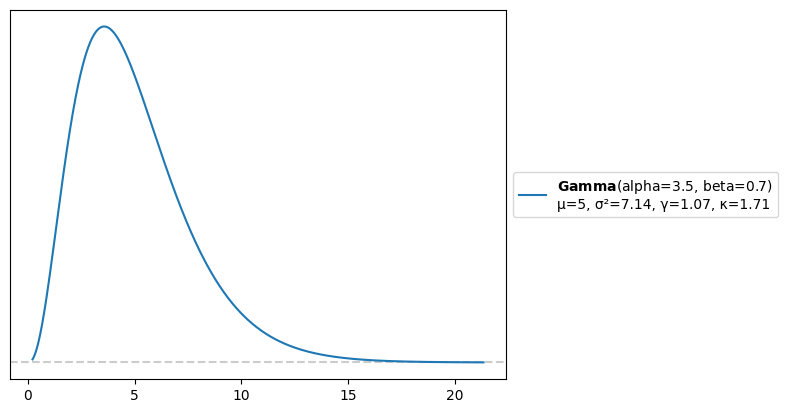

In [45]:
pz.Gamma(alpha = 3.5, beta = 0.7).plot_pdf(moments='mvsk')

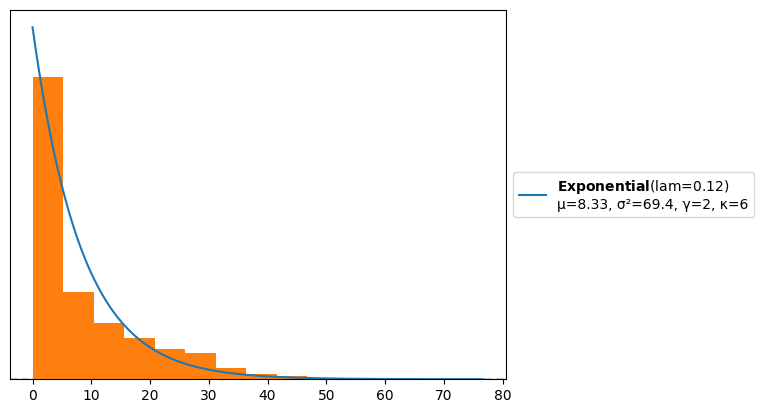

In [67]:
ax = pz.Exponential(lam=0.12).plot_pdf(moments='mvsk')
ax.hist(data.I_F_goals, density=True)

plt.show()

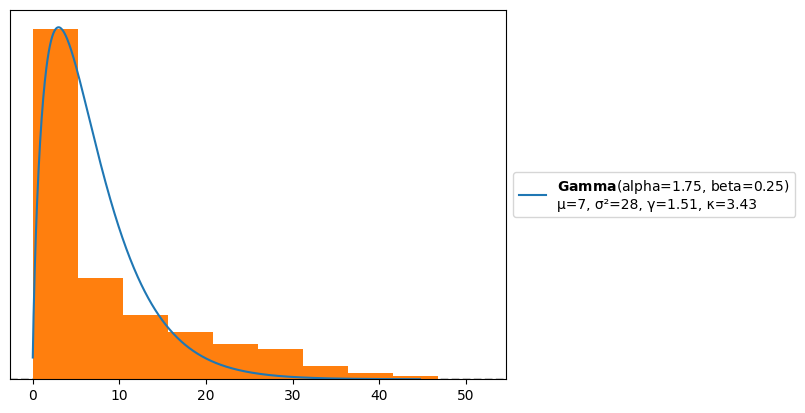

In [85]:
ax = pz.Gamma(alpha = 1.75, beta = 0.25).plot_pdf(moments='mvsk')
ax.hist(data.I_F_goals, density=True)

plt.show()

1.750000000000001
1.7499999999999984


<Axes: >

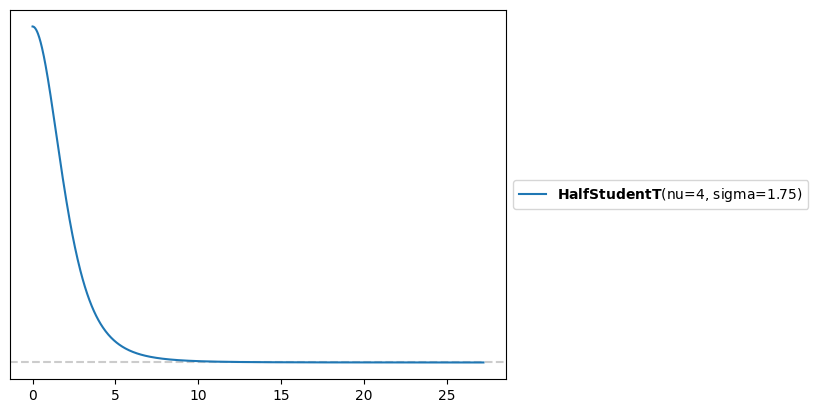

In [105]:
n = 4
s = 1.75
print(pz.HalfStudentT(nu = n, sigma = s).mean())
print(pz.HalfStudentT(nu = n, sigma = s).std())
pz.HalfStudentT(nu = n, sigma = s).plot_pdf()

<Axes: >

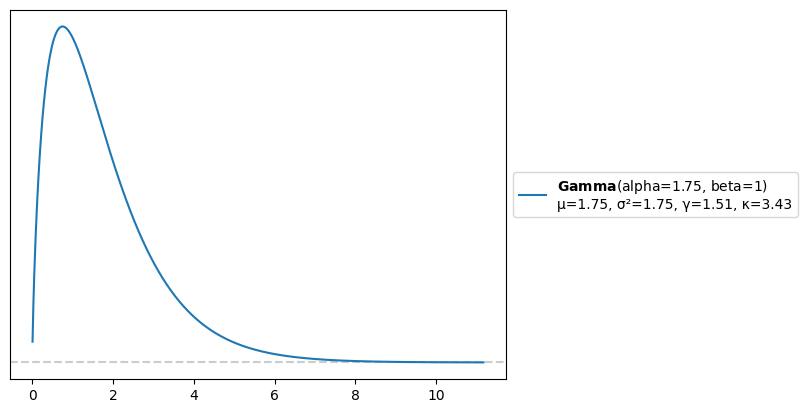

In [108]:
pz.Gamma(alpha = 1.75, beta = 1).plot_pdf(moments='mvsk')

1.750000000000001
1.7499999999999984


<Axes: >

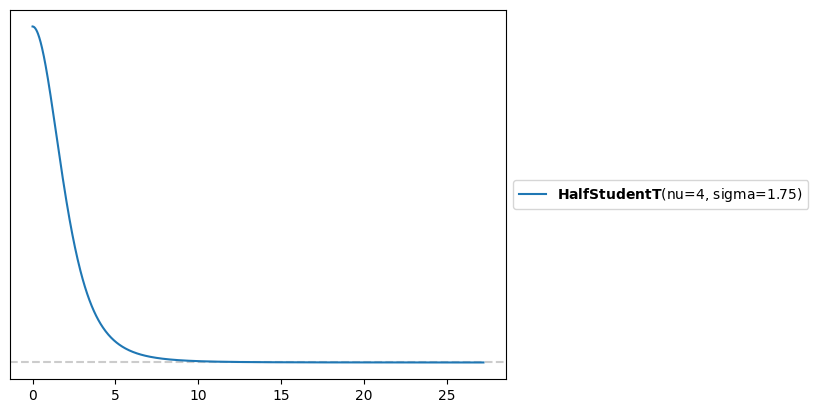

In [109]:
n1 = 4
s1 = 1.75
print(pz.HalfStudentT(nu = n1, sigma = s1).mean())
print(pz.HalfStudentT(nu = n1, sigma = s1).std())
pz.HalfStudentT(nu = n1, sigma = s1).plot_pdf()

<Axes: >

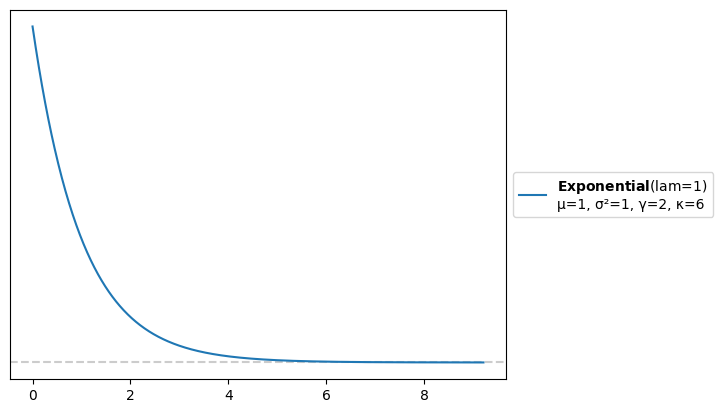

In [110]:
pz.Exponential(lam=1).plot_pdf(moments='mvsk')

In [34]:
data.I_F_goals.std

9.835722846518008

In [ ]:
with pm.Model(coords=aa_coords) as nh_model_test:
    # hyperpriors
    μ_mu_n = pm.Exponential('μ_mu', lam = 1) #1
    μ_nu_n = pm.HalfStudentT('μ_nu', nu = 4, sigma = 1.75) # 1.75

    # priors

    μ_n = pm.Gamma('μ', alpha = μ_nu_n, beta = μ_mu_n, dims = "position")

    # Added prior for nu of v_ne
    nu_v_n = pm.Gamma('nu_v', alpha = 0.25, beta = 1)

    # nu_v_n mean = 4
    v_n = pm.HalfStudentT('v', sigma = nu_v_n, nu = μ_n, dims = "position") # Used nu_v_n here

    #likelihood
    # Add a small constant to the observed data to avoid zeros
    # v_n mean = 1.75
    # mu_n mean = 0.25
    y_n = pm.Gamma('y', # Changed from pm.Normal to pm.StudentT
                  alpha = v_n[aa_idx],
                  beta = μ_n[aa_idx],
                  observed = data['I_F_goals'] + 1e-6) # Added 1e-6 here

    #hierarchical (h)
    data_nh_test = pm.sample()

In [ ]:
with pm.Model(coords=aa_coords) as nh_model:
    # hyperpriors
    μ_mu_n = pm.StudentT('μ_mu', mu = 0, sigma = 10, nu = 30)
    μ_sd_n = pm.HalfStudentT('μ_sd', nu = 30, sigma = 10) # Added nu for HalfStudentT
    μ_nu_n = pm.HalfStudentT('μ_nu', nu = 30, sigma = 10) # Added nu for HalfStudentT

    # priors
    μ_n = pm.StudentT('μ', nu = μ_nu_n, mu = μ_mu_n, sigma = μ_sd_n, dims = "position")

    # Added prior for nu of v_n
    nu_v_n = pm.HalfNormal('nu_v', sigma = 10)
    v_n = pm.HalfStudentT('v', nu = nu_v_n, sigma = 10, dims = "position") # Used nu_v_n here

    σ_n = pm.HalfStudentT('σ', nu = 30, sigma = 10, dims = "position") # Added nu for HalfStudentT

    #likelihood
    y_n = pm.StudentT('y', # Changed from pm.Normal to pm.StudentT
                  nu = v_n[aa_idx],
                  mu = μ_n[aa_idx],
                  sigma = σ_n[aa_idx],
                  observed = data.I_F_goals)

    #hierarchical (h)
    data_nh = pm.sample()

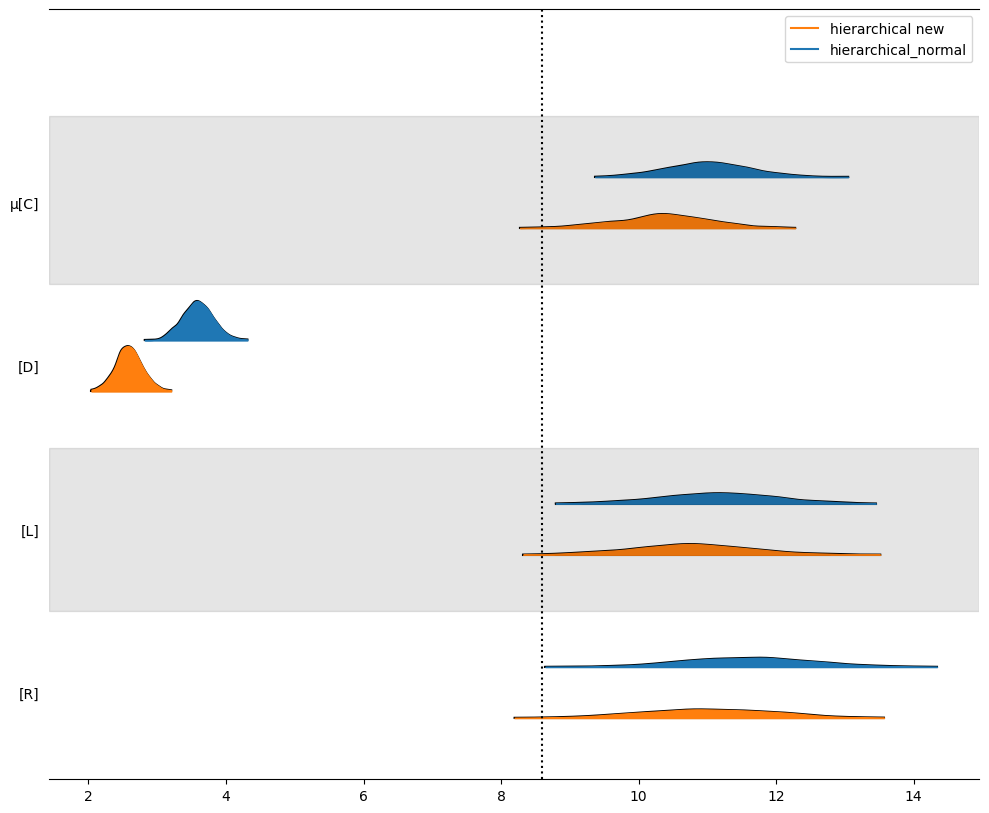

In [135]:
axes = az.plot_forest([data_h, data_nh], kind="ridgeplot",
                      model_names=['hierarchical_normal', 'hierarchical new'],
                      var_names=['μ'], combined=True, figsize=(12, 10),hdi_prob=0.997)

#plots overall mean of the hierarchical model; do not confuse with 0
y_lims = axes[0].get_ylim()
axes[0].vlines(data_h.posterior['μ_mu'].mean(), *y_lims, color="k", ls=":");

In [ ]:
pm.sample_posterior_predictive(data_h, model=h_model, extend_inferencedata=True, progressbar=False)

(-1.0, 55.0)

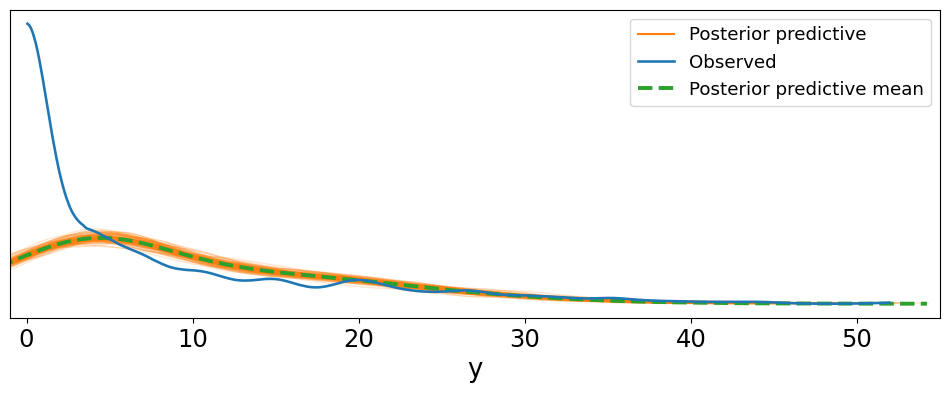

In [139]:
az.plot_ppc(data_h, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C2"])
plt.xlim([-1,55])

In [ ]:
pm.sample_posterior_predictive(data_nh, model=nh_model, extend_inferencedata=True, progressbar=False)

(-1.0, 55.0)

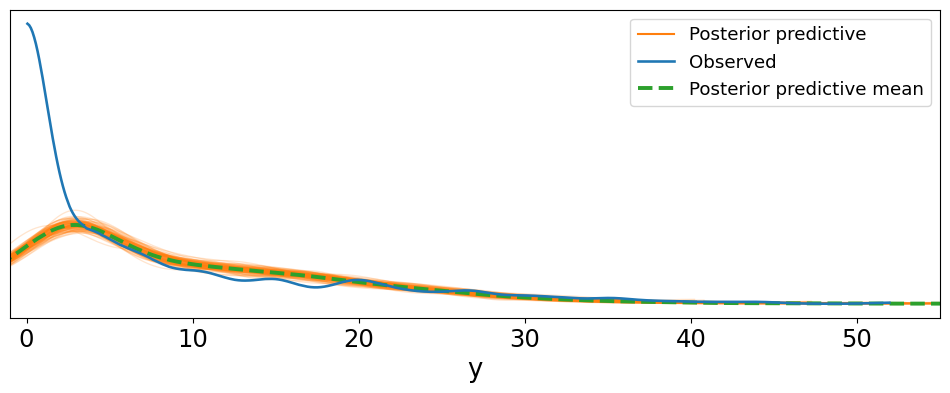

In [144]:
az.plot_ppc(data_nh, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C2"])
# Calculate a reasonable x-axis range based on the observed data
plt.xlim([-1, 55]) #highest goal amount = 52